<a href="https://www.kaggle.com/code/sonawanelalitsunil/student-stress-monitoring-ml-88-64?scriptVersionId=257627475" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-stress-monitoring-datasets/StressLevelDataset.csv
/kaggle/input/student-stress-monitoring-datasets/Stress_Dataset.csv


## Title: 
Student Stress Monitoring Datasets

## Description:
This collection of datasets is designed to study and monitor stress levels among students using various academic, behavioral, physiological, and lifestyle factors. The datasets typically include information such as demographics (age, gender, academic year), academic workload (study hours, assignments, exam schedules), lifestyle patterns (sleep quality, physical activity, diet, screen time), and psychological indicators (self-reported stress levels, anxiety, depression scores). In some cases, biometric or sensor-based data such as heart rate, galvanic skin response (GSR), and EEG signals are also included to provide objective measurements of stress.

The datasets can be used for:

Predictive modeling of student stress levels.

Identifying correlations between lifestyle, academics, and stress.

Developing early warning systems to detect high stress or burnout.

Designing interventions such as relaxation programs, time management strategies, or wellness activities.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/student-stress-monitoring-datasets/StressLevelDataset.csv")

In [3]:
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [4]:
df.tail()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
1095,11,17,0,14,3,1,3,2,2,2,...,3,2,2,2,3,3,2,3,3,1
1096,9,12,0,8,0,3,0,0,0,1,...,4,0,1,1,1,1,3,4,3,2
1097,4,26,0,3,1,2,5,2,2,3,...,4,5,1,4,1,3,1,2,1,0
1098,21,0,1,19,5,3,1,4,3,1,...,1,2,5,1,4,1,4,4,4,2
1099,18,6,1,15,3,3,0,3,3,0,...,3,3,4,3,3,1,5,1,4,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [6]:
df.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


In [7]:
df.dtypes

anxiety_level                   int64
self_esteem                     int64
mental_health_history           int64
depression                      int64
headache                        int64
blood_pressure                  int64
sleep_quality                   int64
breathing_problem               int64
noise_level                     int64
living_conditions               int64
safety                          int64
basic_needs                     int64
academic_performance            int64
study_load                      int64
teacher_student_relationship    int64
future_career_concerns          int64
social_support                  int64
peer_pressure                   int64
extracurricular_activities      int64
bullying                        int64
stress_level                    int64
dtype: object

In [8]:
df.shape

(1100, 21)

In [9]:
df.isnull().sum()

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'academic_performance', 'study_load', 'teacher_student_relationship',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying', 'stress_level'],
      dtype='object')

## Data visualizations

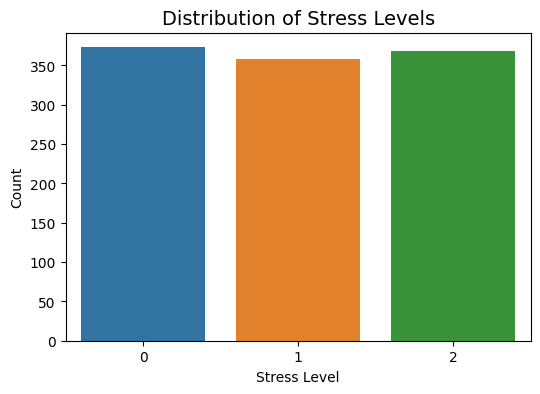

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="stress_level", data=df)
plt.title("Distribution of Stress Levels", fontsize=14)
plt.xlabel("Stress Level")
plt.ylabel("Count")
plt.show()

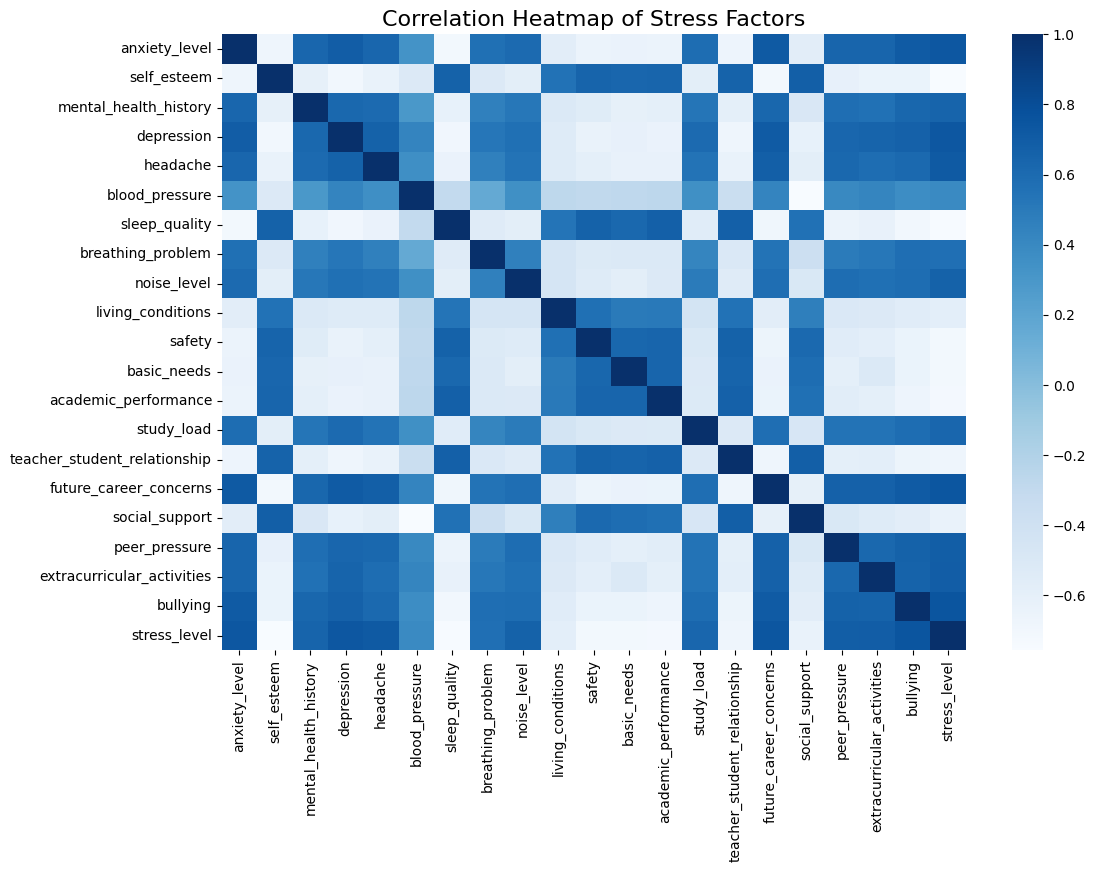

In [13]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap="Blues", cbar=True)
plt.title("Correlation Heatmap of Stress Factors", fontsize=16)
plt.show()

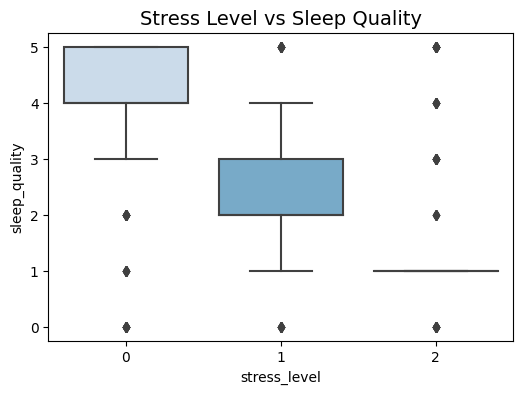

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x="stress_level", y="sleep_quality", data=df, palette="Blues")
plt.title("Stress Level vs Sleep Quality", fontsize=14)
plt.show()

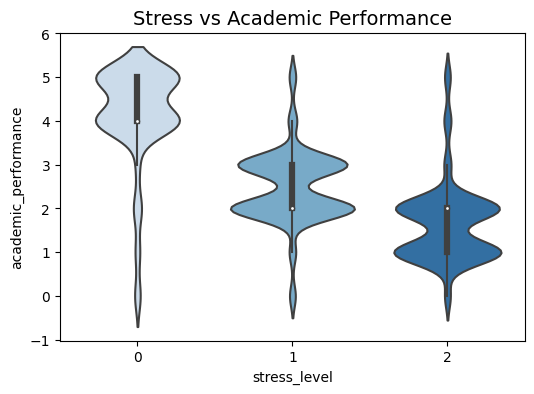

In [15]:
plt.figure(figsize=(6,4))
sns.violinplot(x="stress_level", y="academic_performance", data=df, palette="Blues")
plt.title("Stress vs Academic Performance", fontsize=14)
plt.show()

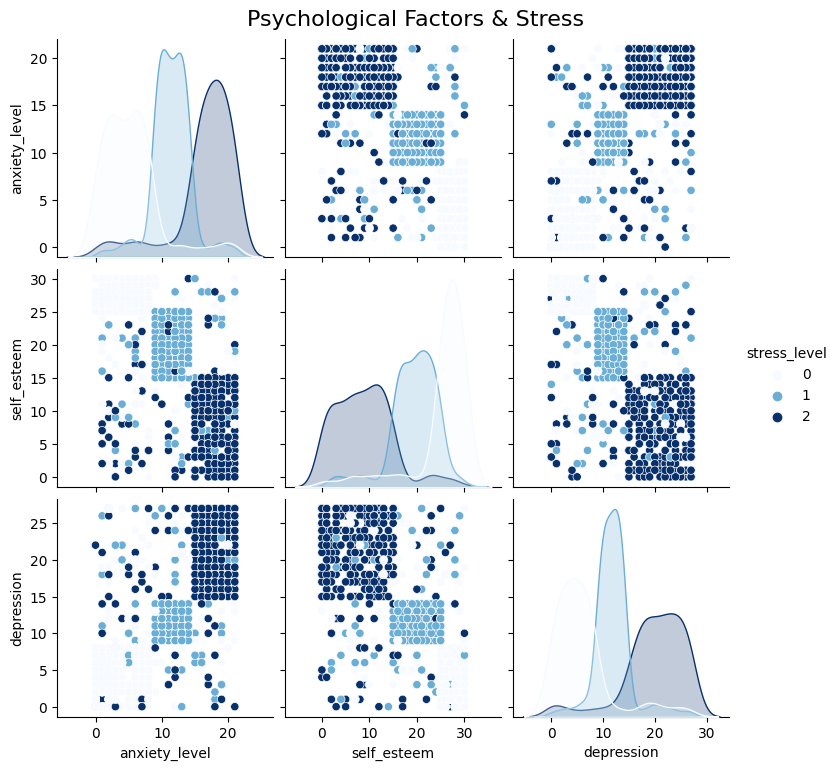

In [16]:
psych_cols = ["anxiety_level", "self_esteem", "depression", "stress_level"]
sns.pairplot(df[psych_cols], hue="stress_level", palette="Blues", diag_kind="kde")
plt.suptitle("Psychological Factors & Stress", y=1.02, fontsize=16)
plt.show()

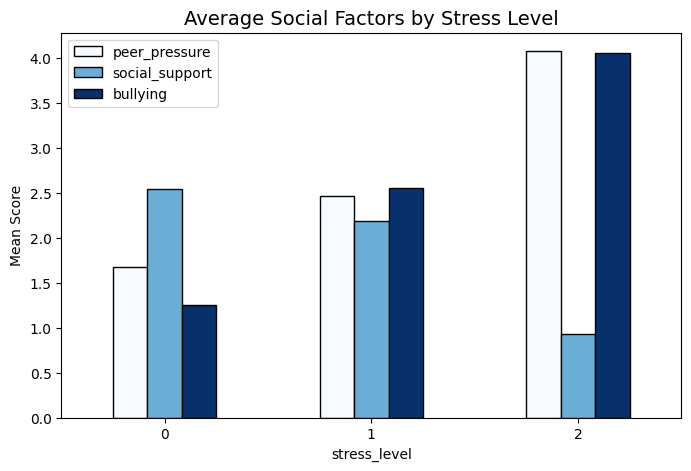

In [17]:
social_cols = ["peer_pressure", "social_support", "bullying"]
mean_stress = df.groupby("stress_level")[social_cols].mean()

mean_stress.plot(kind="bar", figsize=(8,5), colormap="Blues", edgecolor="black")
plt.title("Average Social Factors by Stress Level", fontsize=14)
plt.ylabel("Mean Score")
plt.xticks(rotation=0)
plt.show()

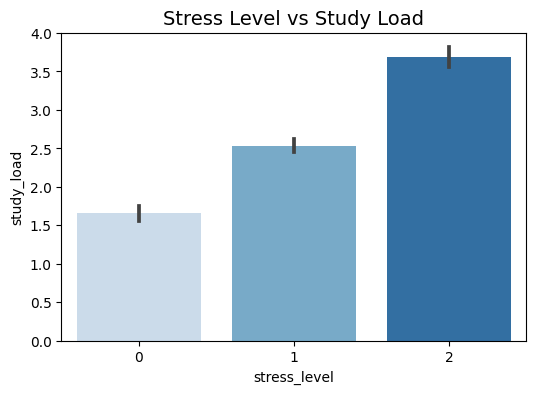

In [18]:
plt.figure(figsize=(6,4))
sns.barplot(x="stress_level", y="study_load", data=df, palette="Blues")
plt.title("Stress Level vs Study Load", fontsize=14)
plt.show()

## Predictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

In [20]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Features and Target
X = df.drop("stress_level", axis=1)
y = df["stress_level"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss")
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = round(acc, 2)


In [22]:
results_df = pd.DataFrame(list(results.items()), columns=["Algorithm", "Accuracy (%)"])
print(results_df)

             Algorithm  Accuracy (%)
0  Logistic Regression         88.18
1        Decision Tree         86.36
2        Random Forest         89.09
3    Gradient Boosting         87.27
4                  KNN         87.27
5                  SVM         88.64
6              XGBoost         87.27


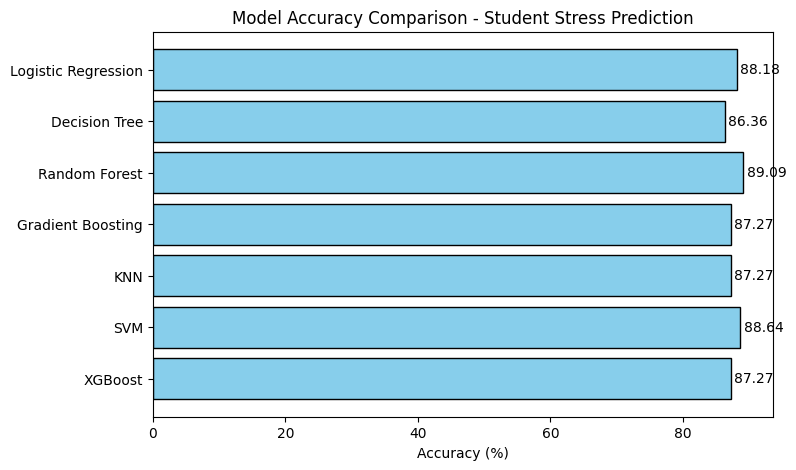

In [23]:
plt.figure(figsize=(8,5))
plt.barh(results_df["Algorithm"], results_df["Accuracy (%)"], color="skyblue", edgecolor="black")
plt.xlabel("Accuracy (%)")
plt.title("Model Accuracy Comparison - Student Stress Prediction")
plt.gca().invert_yaxis()
for i, v in enumerate(results_df["Accuracy (%)"]):
    plt.text(v+0.5, i, str(v), va="center")
plt.show()

## Thank you..pls upvote!!!!